Epoch: 392  |  Loss: 0.143119  |  c: 0.003712  |  LR: 5.11e-03
Epoch: 393  |  Loss: 0.177203  |  c: 0.004638  |  LR: 5.10e-03
Epoch: 394  |  Loss: 0.146158  |  c: 0.003795  |  LR: 5.09e-03
Epoch: 395  |  Loss: 0.146855  |  c: 0.003814  |  LR: 5.07e-03
Epoch: 396  |  Loss: 0.142208  |  c: 0.003688  |  LR: 5.06e-03
Epoch: 397  |  Loss: 0.209042  |  c: 0.005505  |  LR: 5.05e-03
Epoch: 398  |  Loss: 0.142799  |  c: 0.003704  |  LR: 5.04e-03
Epoch: 399  |  Loss: 0.178626  |  c: 0.004678  |  LR: 5.02e-03
Epoch: 400  |  Loss: 0.143029  |  c: 0.003711  |  LR: 5.01e-03
Total training time: 300.4s


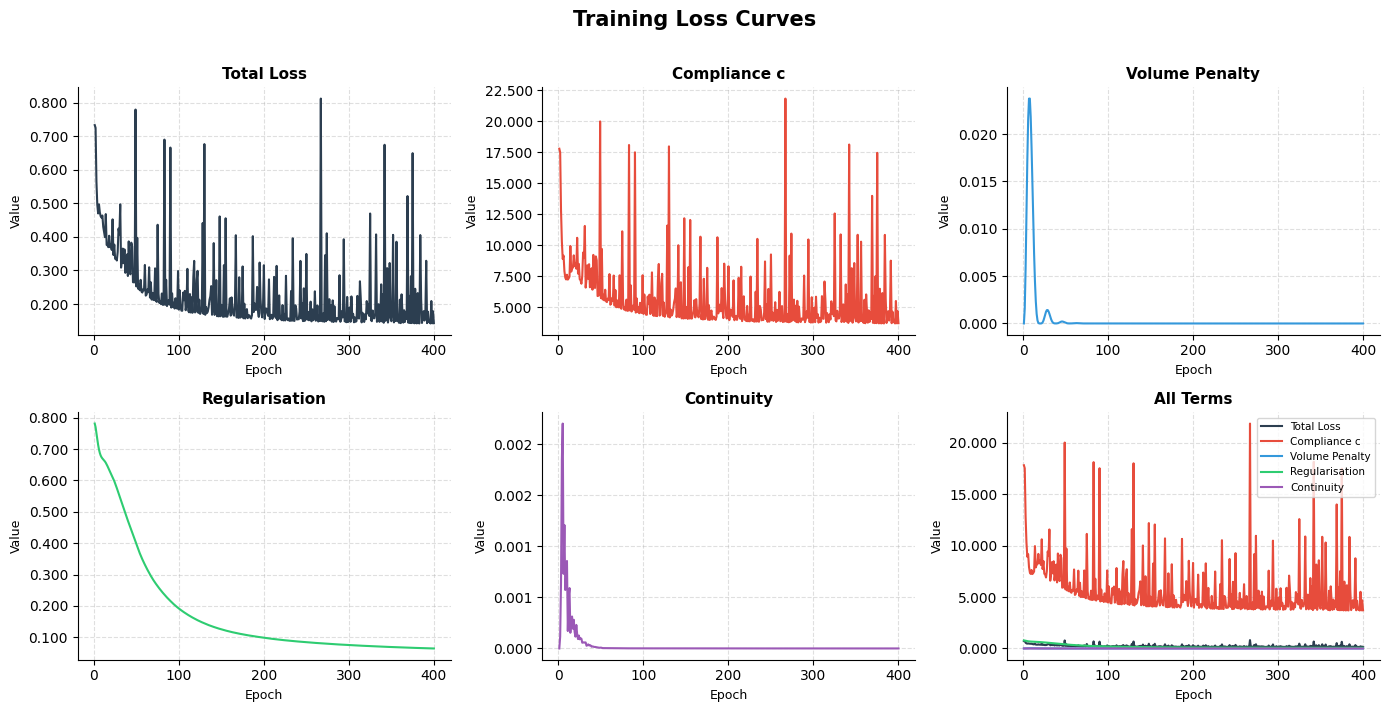

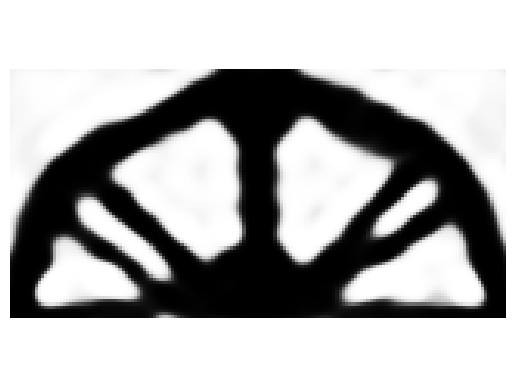

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from IPython import display
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import time

device = 'cuda:2'


# ══════════════════════════════════════════════════════════════════════════════
#  Problem definitions
# ══════════════════════════════════════════════════════════════════════════════

class Problems():
    def dlX_disp(self):
        n_bc     = self.dlX_fixed.shape[0]
        n_force  = self.dlX_force.shape[0]
        n_domain = self.batch_size - n_bc - n_force
        # domain bounds: x ∈ [-nelx/(2·nelm), nelx/(2·nelm)], same for y
        x_lo = -self.nelx / (2 * self.nelm)
        x_hi =  self.nelx / (2 * self.nelm)
        y_lo = -self.nely / (2 * self.nelm)
        y_hi =  self.nely / (2 * self.nelm)
        domain_x = np.random.uniform(x_lo, x_hi, (n_domain, 1))
        domain_y = np.random.uniform(y_lo, y_hi, (n_domain, 1))
        domain_coord = np.concatenate((domain_y, domain_x), axis=1)  # (y, x)
        coord = np.concatenate(
            (self.dlX_fixed.cpu().detach().numpy(),
             self.dlX_force.cpu().detach().numpy(),
             domain_coord),
            axis=0
        )
        return torch.tensor(coord, dtype=torch.float32, requires_grad=True).to(device)


# ──────────────────────────────────────────────────────────────────────────────
#  MBB beam
# ──────────────────────────────────────────────────────────────────────────────
class MBB_Beam_2D(Problems):
    """
    MBB beam — coords = (y, x), nelm = nelx // 2.

    Domain:   x ∈ [-1, 1],  y ∈ [-0.5, 0.5]   (bottom edge = y = +0.5)

    BC:       u_y = 0  at  (x = ±1, y = 0.5)   roller supports, soft penalty
    Load:     F_y = 1  at  (x =  0, y = 0.5)   downward point force
    """

    def __init__(self, nelx, nely, vf):
        self.nelx = nelx
        self.nely = nely
        self.nele = nelx * nely

        # ── KEY FIX: nelm = nelx // 2  so that x ∈ [-1,1], y ∈ [-0.5,0.5] ──
        assert nelx == 2 * nely, \
            f"MBB beam expects nelx = 2*nely (got {nelx}, {nely})"
        self.nelm = nelx // 2          # = nely  →  x:[-1,1], y:[-0.5,0.5]

        self.volfrac    = vf
        self.E0         = 1
        self.nu         = 0.3
        self.batch_size = 25000
        self.alpha_init  = 1
        self.alpha_max   = 100
        self.alpha_delta = 0.5
        self.penal       = 3.0

        # ── mesh (coords stored as [y, x]) ────────────────────────────────────
        # x_range = [-nelx/(2*nelm), nelx/(2*nelm)] = [-1, 1]
        # y_range = [-nely/(2*nelm), nely/(2*nelm)] = [-0.5, 0.5]
        c_y, c_x = np.meshgrid(
            np.linspace(-nely / (2 * self.nelm),  nely / (2 * self.nelm),  nely),
            np.linspace(-nelx / (2 * self.nelm),  nelx / (2 * self.nelm),  nelx),
            indexing='ij'
        )
        self.dlX = np.stack((c_y.reshape(-1), c_x.reshape(-1)), axis=1)

        c_y2, c_x2 = np.meshgrid(
            np.linspace(-nely / (2 * self.nelm),  nely / (2 * self.nelm),  2 * nely),
            np.linspace(-nelx / (2 * self.nelm),  nelx / (2 * self.nelm),  2 * nelx),
            indexing='ij'
        )
        self.dlXSS = np.stack((c_y2.reshape(-1), c_x2.reshape(-1)), axis=1)
        self.V = (np.max(self.dlX[:, 0]) - np.min(self.dlX[:, 0])) * \
                 (np.max(self.dlX[:, 1]) - np.min(self.dlX[:, 1]))

        # Verify domain (sanity check printed at construction)
        x_min, x_max = self.dlX[:, 1].min(), self.dlX[:, 1].max()
        y_min, y_max = self.dlX[:, 0].min(), self.dlX[:, 0].max()
        print(f"[MBB_Beam_2D] domain  x ∈ [{x_min:.4f}, {x_max:.4f}]  "
              f"y ∈ [{y_min:.4f}, {y_max:.4f}]")

        # ── bottom edge coordinate  (y = +0.5 in this mesh) ─────────────────
        y_bottom = float(nely / (2 * self.nelm))   # = +0.5

        # ── Roller supports: exact single points at (x=±1, y=0.5) ───────────
        # coords = (y, x), so each row is [y_bottom, x_support]
        dlX_fixed = np.array([
            [y_bottom, -1.0],   # bottom-left  corner:  u_y = 0
            [y_bottom,  1.0],   # bottom-right corner:  u_y = 0
        ], dtype=np.float32)

        # ── Force point: (x=0, y=0.5) — downward F_y = 1 ───────────────────
        dlX_force = np.array([
            [y_bottom, 0.0],    # bottom-centre
        ], dtype=np.float32)

        # F_vector[0] = 1 → force in y-direction (index 0 = u_y component)
        # F_vector[1] = 0 → no horizontal force
        self.F_vector = torch.tensor([[1.0], [0.0]], dtype=torch.float32).to(device)

        print(f"[MBB_Beam_2D] fixed BC at  {dlX_fixed.tolist()}  (u_y = 0)")
        print(f"[MBB_Beam_2D] force at     {dlX_force.tolist()}  (F_y = 1, downward)")

        # ── to tensors ────────────────────────────────────────────────────────
        self.dlX       = torch.tensor(self.dlX,    dtype=torch.float32, requires_grad=True).to(device)
        self.dlXSS     = torch.tensor(self.dlXSS,  dtype=torch.float32, requires_grad=True).to(device)
        self.dlX_fixed = torch.tensor(dlX_fixed,   dtype=torch.float32, requires_grad=True).to(device)
        self.dlX_force = torch.tensor(dlX_force,   dtype=torch.float32, requires_grad=True).to(device)


# ══════════════════════════════════════════════════════════════════════════════
#  Spectral network backbone
# ══════════════════════════════════════════════════════════════════════════════

_BAND_LOW, _BAND_HIGH = 0.0, 10.0
def _build_spectral_kernel(n_y=10, n_x=10,
                           band_low=_BAND_LOW, band_high=_BAND_HIGH):
    c_y, c_x = np.meshgrid(
        np.linspace([-band_high, band_low], [-band_low, band_high], n_y).ravel(),
        np.linspace([-band_high, band_low], [-band_low, band_high], n_x).ravel(),
        indexing='ij',
    )
    return torch.tensor(
        np.stack((c_y.ravel(), c_x.ravel()), axis=0), dtype=torch.float32
    )


class _SpectralBase(nn.Module):
    def __init__(self, trainable_kernel, n_y=10, n_x=10,
                 band_low=_BAND_LOW, band_high=_BAND_HIGH):
        super().__init__()
        K = _build_spectral_kernel(n_y, n_x, band_low, band_high).to(device)
        if trainable_kernel:
            self.kernel1 = nn.Parameter(K)
        else:
            self.register_buffer('kernel1', K)
        self.register_buffer('_bias', torch.ones(1, K.shape[1], dtype=torch.float32).to(device))

    def _features(self, x):
        return torch.sin(x @ self.kernel1 + self._bias)


class Disp_Net(_SpectralBase):
    def __init__(self, n_y=20, n_x=20, band_low=_BAND_LOW, band_high=_BAND_HIGH):
        super().__init__(trainable_kernel=False, n_y=n_y, n_x=n_x,
                         band_low=band_low, band_high=band_high)

    def forward(self, x):
        return self._features(x)


class TO_BlockNet(nn.Module):
    def __init__(self, n_cols=2, n_rows=2, n_y=2, n_x=3,
                 band_low=_BAND_LOW, band_high=_BAND_HIGH,
                 overlap=0.0, device='cuda:2'):
        super().__init__()
        self.n_cols   = int(n_cols)
        self.n_rows   = int(n_rows)
        self.n_blocks = self.n_cols * self.n_rows
        self.overlap  = overlap
        self.device   = device

        K = _build_spectral_kernel(n_y, n_x, band_low, band_high).to(device)
        self.M = K.shape[1]
        self.kernels = nn.Parameter(K.unsqueeze(0).expand(self.n_blocks, -1, -1).clone())
        self.weights = nn.Parameter(torch.zeros(self.n_blocks, self.M, device=device))

    def _block_indices(self, coords):
        ys, xs = coords[:, 0], coords[:, 1]
        min_y, max_y = ys.min(), ys.max()
        min_x, max_x = xs.min(), xs.max()
        col = ((xs - min_x) / (max_x - min_x + 1e-9) * self.n_cols).long().clamp(0, self.n_cols - 1)
        row = ((ys - min_y) / (max_y - min_y + 1e-9) * self.n_rows).long().clamp(0, self.n_rows - 1)
        return row * self.n_cols + col

    def _soft_weights(self, coords):
        ys = coords[:, 0:1]
        xs = coords[:, 1:2]
        min_y, max_y = ys.min().item(), ys.max().item()
        min_x, max_x = xs.min().item(), xs.max().item()
        block_h = (max_y - min_y) / self.n_rows
        block_w = (max_x - min_x) / self.n_cols
        centers_y = torch.tensor(
            [min_y + (r + 0.5) * block_h for r in range(self.n_rows) for c in range(self.n_cols)],
            dtype=torch.float32, device=self.device)
        centers_x = torch.tensor(
            [min_x + (c + 0.5) * block_w for r in range(self.n_rows) for c in range(self.n_cols)],
            dtype=torch.float32, device=self.device)
        sigma_y = block_h * (0.5 + self.overlap)
        sigma_x = block_w * (0.5 + self.overlap)
        dy = (ys - centers_y.unsqueeze(0)) / sigma_y
        dx = (xs - centers_x.unsqueeze(0)) / sigma_x
        return torch.softmax(-0.5 * (dy ** 2 + dx ** 2), dim=1)

    def _all_blocks(self, coords):
        N, B, M = coords.shape[0], self.n_blocks, self.M
        K_flat = self.kernels.permute(1, 0, 2).reshape(2, B * M)
        z = (coords @ K_flat).view(N, B, M) + 1.0
        return torch.sigmoid((torch.sin(z) * self.weights.unsqueeze(0)).sum(dim=2))

    def forward(self, coords):
        coords  = coords.to(self.device)
        out_all = self._all_blocks(coords)
        if self.overlap <= 0:
            bidx = self._block_indices(coords)
            N = coords.shape[0]
            return out_all[torch.arange(N, device=self.device), bidx].unsqueeze(-1)
        else:
            w = self._soft_weights(coords)
            return (out_all * w).sum(dim=1, keepdim=True)

    def eval_block(self, idx, coords):
        coords = coords.to(self.device)
        z = coords @ self.kernels[idx] + 1.0
        return torch.sigmoid(torch.sin(z) @ self.weights[idx].unsqueeze(-1))

    def num_blocks(self):
        return self.n_blocks


# ══════════════════════════════════════════════════════════════════════════════
#  Analytical basis-matrix computation
# ══════════════════════════════════════════════════════════════════════════════

def cal_matrix(model: Disp_Net, points: torch.Tensor,
               dlx_force: torch.Tensor, M: int,
               dlx_fixed: torch.Tensor = None):
    """
    Compute RFM basis matrix and its spatial gradients (raw spectral features).
    BC is enforced externally via soft penalty in pinnloss2.

    Returns
    -------
    (u1, u_x, u_y, v_force)              when dlx_fixed is None
    (u1, u_x, u_y, v_force, v_fixed)     when dlx_fixed is provided
    """
    K = model.kernel1  # [2, M]

    with torch.no_grad():
        z     = points @ K + model._bias   # [N, M]
        sin_z = torch.sin(z)
        cos_z = torch.cos(z)

        u1  = sin_z                        # [N, M]
        u_y = cos_z * K[0:1, :]           # [N, M]
        u_x = cos_z * K[1:2, :]           # [N, M]

        v_force = model(dlx_force)         # [n_force, M]
        v_fixed = model(dlx_fixed) if dlx_fixed is not None else None

    result = (u1.cpu().numpy(),
              u_x.cpu().numpy(),
              u_y.cpu().numpy(),
              v_force.cpu().numpy())
    if v_fixed is not None:
        result = result + (v_fixed.cpu().numpy(),)
    return result


# ══════════════════════════════════════════════════════════════════════════════
#  PDE / energy loss
# ══════════════════════════════════════════════════════════════════════════════

_E_MOD, _NU_MOD  = 1000.0, 0.3
_LAME_MU         = _E_MOD / (2.0 * (1.0 + _NU_MOD))
_LAME_LAMBDA     = _E_MOD * _NU_MOD / (1.0 - _NU_MOD ** 2)


def pinnloss2(weights1, u_x, u_y, v_force, problem, xPhys_m,
              v_fixed=None, bc_weight=100.0):
    """
    Minimum potential-energy loss.

    For the MBB beam pass v_fixed (basis matrix at roller supports) and
    bc_weight.  The penalty  bc_weight * mean(u_y_fixed²)  enforces u_y=0
    at the two roller-support locations.

    Parameters
    ----------
    v_fixed    : Tensor [n_fixed, M] or None
        Basis matrix at fixed (roller) points. Only used for MBB beam.
    bc_weight  : float
        Penalty coefficient for the displacement BC (MBB only).
    """
    xPhys_m = xPhys_m.reshape(-1, 1)

    # Strain components
    ux = (u_x @ weights1[:, 1]).reshape(-1, 1)   # ∂u_x/∂x
    uy = (u_y @ weights1[:, 1]).reshape(-1, 1)   # ∂u_x/∂y
    vx = (u_x @ weights1[:, 0]).reshape(-1, 1)   # ∂u_y/∂x
    vy = (u_y @ weights1[:, 0]).reshape(-1, 1)   # ∂u_y/∂y

    eps11 = ux
    eps12 = 0.5 * (uy + vx)
    eps22 = vy

    trace_sq = (eps11 + eps22) ** 2
    diag_sq  = eps11 * eps11 + eps22 * eps22
    energy   = (0.5 * _LAME_LAMBDA * trace_sq
                + _LAME_MU * (diag_sq + 2.0 * eps12 * eps12))
    energy   = energy * (xPhys_m ** 3.0)

    energy_ans = problem.V * torch.mean(energy)

    # External work: F_vector[0]=1 → force in y-direction (index 0 of weights1)
    F_scale = float(problem.F_vector[0].item())
    force_l = torch.mean(F_scale * (v_force @ weights1[:, 0]).reshape(-1, 1))

    loss = energy_ans - force_l

    # ── MBB soft BC penalty: u_y = 0 at roller supports ────────────────────
    # weights1[:, 0] is the u_y component (index 0 ↔ y-direction)
    if v_fixed is not None:
        u_y_fixed = (v_fixed @ weights1[:, 0]).reshape(-1, 1)
        bc_loss   = torch.mean(u_y_fixed ** 2)
        loss      = loss + bc_weight * bc_loss

    return loss, energy


# ══════════════════════════════════════════════════════════════════════════════
#  Block continuity loss
# ══════════════════════════════════════════════════════════════════════════════

def continueloss(to_model: TO_BlockNet, problem) -> torch.Tensor:
    n_samples = 500
    min_y = torch.min(problem.dlX[:, 0]).item()
    max_y = torch.max(problem.dlX[:, 0]).item()
    min_x = torch.min(problem.dlX[:, 1]).item()
    max_x = torch.max(problem.dlX[:, 1]).item()

    losses = []

    # Vertical interfaces (column boundaries)
    for k in range(to_model.n_cols - 1):
        iface_x = min_x + (k + 1) * (max_x - min_x) / to_model.n_cols
        ys  = torch.linspace(min_y, max_y, n_samples, device=to_model.device).unsqueeze(1)
        pts = torch.cat([ys, torch.full_like(ys, iface_x)], dim=1)
        all_out = to_model._all_blocks(pts)
        row_idx = ((ys.squeeze(1) - min_y) / (max_y - min_y + 1e-9)
                   * to_model.n_rows).long().clamp(0, to_model.n_rows - 1)
        for r in range(to_model.n_rows):
            mask = (row_idx == r)
            if mask.sum() == 0:
                continue
            losses.append(torch.mean(
                (all_out[mask, r * to_model.n_cols + k]
               - all_out[mask, r * to_model.n_cols + k + 1]) ** 2))

    # Horizontal interfaces (row boundaries)
    for k in range(to_model.n_rows - 1):
        iface_y = min_y + (k + 1) * (max_y - min_y) / to_model.n_rows
        xs  = torch.linspace(min_x, max_x, n_samples, device=to_model.device).unsqueeze(1)
        pts = torch.cat([torch.full_like(xs, iface_y), xs], dim=1)
        all_out = to_model._all_blocks(pts)
        col_idx = ((xs.squeeze(1) - min_x) / (max_x - min_x + 1e-9)
                   * to_model.n_cols).long().clamp(0, to_model.n_cols - 1)
        for c in range(to_model.n_cols):
            mask = (col_idx == c)
            if mask.sum() == 0:
                continue
            losses.append(torch.mean(
                (all_out[mask, k * to_model.n_cols + c]
               - all_out[mask, (k + 1) * to_model.n_cols + c]) ** 2))

    if not losses:
        return torch.tensor(0.0, device=to_model.device)
    return torch.stack(losses).mean()


# ══════════════════════════════════════════════════════════════════════════════
#  Main solver
# ══════════════════════════════════════════════════════════════════════════════

class RFM_TONN():

    def __init__(self, problem, to_model, disp_model):
        self.problem    = problem
        self.disp_model = disp_model
        self.to_model   = to_model
        self.total_epoch = 0

        self.to_optimizer = optim.Adam(self.to_model.parameters(), lr=0.01)
        self.to_scheduler = optim.lr_scheduler.LinearLR(
            self.to_optimizer,
            start_factor=1.0,
            end_factor=5e-3 / 1e-2,
            total_iters=400,
        )
        self.coord = problem.dlX_disp()

        M = disp_model.kernel1.shape[1]

        _, u_x, u_y, v_force, v_fixed = cal_matrix(
            self.disp_model, self.coord,
            self.problem.dlX_force, M,
            dlx_fixed=self.problem.dlX_fixed
        )
        self.u_x     = torch.tensor(u_x,     dtype=torch.float32, device=device)
        self.u_y     = torch.tensor(u_y,     dtype=torch.float32, device=device)
        self.v_force = torch.tensor(v_force, dtype=torch.float32, device=device)
        self.v_fixed = torch.tensor(v_fixed, dtype=torch.float32, device=device)

        self.loss_log = {'total': [], 'compliance': [], 'volume': [], 'reg': [], 'continuity': []}

    def fit_disp_init(self):
        M = self.disp_model.kernel1.shape[1]
        self.weights1 = nn.Parameter(
            torch.zeros(M, 2, dtype=torch.float32, device=device)
        )
        self.disp_optimizer = optim.Adam([self.weights1], lr=5e-6)

        xPhys_init = torch.full((self.coord.shape[0], 1), 0.5, device=device)
        for _ in range(1000):
            loss, _ = pinnloss2(
                self.weights1, self.u_x, self.u_y, self.v_force,
                self.problem, xPhys_init, v_fixed=self.v_fixed
            )
            self.disp_optimizer.zero_grad()
            loss.backward()
            self.disp_optimizer.step()

        # Reference compliance on full grid
        _, u_x, u_y, v_force, v_fixed_ref = cal_matrix(
            self.disp_model, self.problem.dlX,
            self.problem.dlX_force, M,
            dlx_fixed=self.problem.dlX_fixed
        )
        u_x         = torch.tensor(u_x,       dtype=torch.float32, device=device)
        u_y         = torch.tensor(u_y,       dtype=torch.float32, device=device)
        v_force     = torch.tensor(v_force,   dtype=torch.float32, device=device)
        v_fixed_ref = torch.tensor(v_fixed_ref, dtype=torch.float32, device=device)

        xPhys_ref = torch.full((self.problem.dlX.shape[0], 1), 0.5, device=device)
        _, energy_c = pinnloss2(
            self.weights1, u_x, u_y, v_force,
            self.problem, xPhys_ref, v_fixed=v_fixed_ref
        )
        self.c1  = energy_c
        self.c_0 = torch.mean(energy_c)

    def to_loss(self, coord):
        self.total_epoch += 1
        xPhys_m = self.to_model(coord)
        alpha   = min(self.problem.alpha_init
                      + self.problem.alpha_delta * self.total_epoch,
                      self.problem.alpha_max)

        _, energy_c = pinnloss2(
            self.weights1, self.u_x, self.u_y, self.v_force,
            self.problem, xPhys_m,
            v_fixed=self.v_fixed
        )

        class ComputeDeDrho(torch.autograd.Function):
            @staticmethod
            def forward(ctx, xPhys_m, energy_c, coord):
                ctx.save_for_backward(xPhys_m, energy_c, coord)
                return energy_c

            @staticmethod
            def backward(ctx, denergy):
                xPhys_m, energy_c, coord = ctx.saved_tensors
                grad_energy = torch.autograd.grad(
                    outputs=energy_c, inputs=xPhys_m,
                    grad_outputs=denergy,
                    create_graph=True, retain_graph=True
                )[0]
                return -grad_energy, torch.zeros_like(energy_c), torch.zeros_like(coord)

        c = torch.mean(ComputeDeDrho.apply(xPhys_m, energy_c, coord))

        xPhys_dlX     = self.to_model(self.problem.dlX)
        continueloss1 = continueloss(self.to_model, self.problem)
        vf            = torch.mean(xPhys_dlX)

        # Phase-field regularisation
        epsilon   = 8e-3
        gamma     = 0.1
        grad_phi  = torch.autograd.grad(
            outputs=xPhys_m.sum(), inputs=coord,
            create_graph=True, retain_graph=True
        )[0]
        grad_term   = 0.5 * epsilon * torch.mean(torch.sum(grad_phi ** 2, dim=1))
        double_well = (1 / epsilon) * torch.mean(xPhys_m ** 2 * (1 - xPhys_m) ** 2)
        reg_term    = gamma * (0.05 * grad_term + double_well)

        loss = (alpha * (vf / self.problem.volfrac - 1.0) ** 2
                + c / self.c_0.detach()
                + 0.1 * reg_term
                + 5 * continueloss1)

        cur_lr = self.to_optimizer.param_groups[0]['lr']
        print(f'Epoch: {self.total_epoch}  |  Loss: {loss.item():.6f}  |  '
              f'c: {c.item():.6f}  |  LR: {cur_lr:.2e}')

        self.loss_log['total'].append(loss.item())
        self.loss_log['compliance'].append(c.item()*1000)
        self.loss_log['volume'].append(((vf / self.problem.volfrac - 1.0) ** 2).item())
        self.loss_log['reg'].append(reg_term.item())
        self.loss_log['continuity'].append(continueloss1.item())
        return loss

    def fit_disp(self, epochs=200):
        for _ in range(epochs):
            xPhys_m = self.to_model(self.coord)
            loss, _ = pinnloss2(
                self.weights1, self.u_x, self.u_y, self.v_force,
                self.problem, xPhys_m,
                v_fixed=self.v_fixed
            )
            self.disp_optimizer.zero_grad()
            loss.backward()
            self.disp_optimizer.step()

    def fit_to(self, epochs=500):
        self.time_pde     = []
        self.time_density = []

        for epoch in range(epochs):
            t0 = time.time()
            self.fit_disp(50)
            self.time_pde.append(time.time() - t0)

            if epoch % 10 == 1:
                display.clear_output(wait=True)

            t0   = time.time()
            loss = self.to_loss(self.coord)
            self.to_optimizer.zero_grad()
            loss.backward()
            self.to_optimizer.step()
            self.to_scheduler.step()
            self.time_density.append(time.time() - t0)

            if (epoch + 1) % 100 == 0:
                xPhys_ss = self.to_model(self.problem.dlXSS.to(device))
                tt = xPhys_ss.cpu().detach().numpy().reshape(
                    2 * self.problem.nely, 2 * self.problem.nelx
                )
                fig, ax = plt.subplots()
                ax.imshow(-tt, cmap='gray')
                ax.axis('equal'); ax.axis('off')
                plt.close(fig)

    def plot_loss(self):
        import matplotlib.ticker as ticker
        log    = self.loss_log
        epochs = np.arange(1, len(log['total']) + 1)
        fig, axes = plt.subplots(2, 3, figsize=(14, 7))
        fig.suptitle('Training Loss Curves', fontsize=15, fontweight='bold', y=1.01)
        items = [
            ('total',      'Total Loss',     '#2C3E50'),
            ('compliance', 'Compliance c',   '#E74C3C'),
            ('volume',     'Volume Penalty', '#3498DB'),
            ('reg',        'Regularisation', '#2ECC71'),
            ('continuity', 'Continuity',     '#9B59B6'),
        ]
        for ax, (key, title, color) in zip(axes.flat, items):
            ax.plot(epochs, log[key], color=color, linewidth=1.5)
            ax.set_title(title, fontsize=11, fontweight='bold')
            ax.set_xlabel('Epoch', fontsize=9); ax.set_ylabel('Value', fontsize=9)
            ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            ax.grid(True, linestyle='--', alpha=0.4)
            ax.spines[['top', 'right']].set_visible(False)
        ax = axes.flat[5]
        for key, title, color in items:
            ax.plot(epochs, log[key], color=color, linewidth=1.5, label=title)
        ax.set_title('All Terms', fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=9); ax.set_ylabel('Value', fontsize=9)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
        ax.legend(fontsize=7.5, loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        plt.savefig('loss_curves.pdf', dpi=300, bbox_inches='tight')
        plt.show()


# ══════════════════════════════════════════════════════════════════════════════
#  Main script
# ══════════════════════════════════════════════════════════════════════════════

# MBB beam: nelm = nelx//2 = 40  →  x ∈ [-1, 1],  y ∈ [-0.5, 0.5]
# u_y = 0  at  (x=−1, y=0.5) and (x=+1, y=0.5)   [roller supports]
# F_y = 1 (downward)  at  (x=0, y=0.5)             [centre load]
nelx, nely, vf = 80, 40, 0.5
problem = MBB_Beam_2D(nelx, nely, vf)

to_model     = TO_BlockNet(n_cols=2, n_rows=2, n_y=10, n_x=10,
                           band_low=0.0, band_high=33.0,
                           overlap=0.2).to(device)
disp_model_h = Disp_Net(n_y=40, n_x=40, band_low=0.0, band_high=33.0).to(device)
M            = disp_model_h.kernel1.shape[1]

opt = RFM_TONN(problem, to_model, disp_model_h)
print(f'Trainable parameters: {sum(p.numel() for p in opt.to_model.parameters() if p.requires_grad)}')

opt.fit_disp_init()

t_start = time.time()
opt.fit_to(400)
print(f'Total training time: {time.time() - t_start:.1f}s')
opt.plot_loss()

# ── Final density field ────────────────────────────────────────────────────────
xPhys_dlX = opt.to_model(opt.problem.dlXSS.to(device))
tt = xPhys_dlX.cpu().detach().numpy().reshape(
    2 * opt.problem.nely, 2 * opt.problem.nelx
)
fig, ax = plt.subplots()
ax.imshow(-tt, cmap='gray')
ax.axis('equal'); ax.axis('off')
fig.savefig('topology_result.pdf', dpi=300)
plt.show()

二值化后体积分数   : 0.5111
去孤岛后体积分数   : 0.5111
连通域数量         : 1


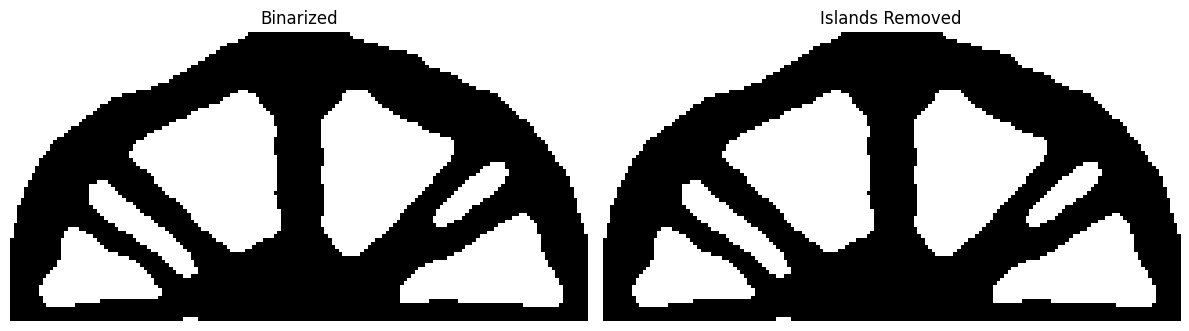

In [2]:
import numpy as np
from scipy.ndimage import label, binary_fill_holes

# ------------------------------------------------------------------ #
#  1. 二值化
# ------------------------------------------------------------------ #
threshold = 0.4
tt_bin = (tt >= threshold).astype(np.uint8)

# ------------------------------------------------------------------ #
#  2. 去除孤岛（保留最大连通域）
# ------------------------------------------------------------------ #
structure = np.ones((3, 3), dtype=int)          # 8-连通
labeled, num_features = label(tt_bin, structure=structure)

if num_features == 0:
    tt_clean = tt_bin.copy()
else:
    # 统计每个连通域的像素数，保留最大的
    component_sizes = np.bincount(labeled.ravel())
    component_sizes[0] = 0                      # 背景不参与比较
    largest_label = component_sizes.argmax()
    tt_clean = (labeled == largest_label).astype(np.uint8)

print(f"二值化后体积分数   : {tt_bin.mean():.4f}")
print(f"去孤岛后体积分数   : {tt_clean.mean():.4f}")
print(f"连通域数量         : {num_features}")

# ------------------------------------------------------------------ #
#  3. 可视化对比
# ------------------------------------------------------------------ #
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(1 - tt_bin,  cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Binarized")
axes[0].axis('off')

axes[1].imshow(1 - tt_clean, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Islands Removed")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("tt_clean.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve


def calc_compliance_mbb(xPhys, penal=3):
    """
    计算 MBB 梁给定密度矩阵的 compliance。

    边界条件
    --------
    - 滚动支撑 (u_y = 0) : 底边左下角节点 (i=nely, j=0)
                           底边右下角节点 (i=nely, j=nelx)
    - 集中载荷 (F_y = -1): 底边中点节点   (i=nely, j=nelx//2)

    节点编号约定 (与 cantilever 版本一致，column-major / Fortran order)
    ---------------------------------------------------------------
    nodenrs[i, j] = j*(nely+1) + i + 1   (1-indexed)
    x-DOF = 2*(node-1),   y-DOF = 2*(node-1)+1

    Parameters
    ----------
    xPhys : np.ndarray, shape (nely, nelx)
        密度矩阵，值域 [0, 1]。
    penal : float
        惩罚指数，默认 3。

    Returns
    -------
    c : float
        结构柔度（compliance）。
    """
    nely, nelx = xPhys.shape

    # ------------------------------------------------------------------ #
    #  MATERIAL PROPERTIES
    # ------------------------------------------------------------------ #
    E0   = 1.0
    Emin = 1e-9
    nu   = 0.3

    # ------------------------------------------------------------------ #
    #  ELEMENT STIFFNESS MATRIX  (与 cantilever 版本完全相同)
    # ------------------------------------------------------------------ #
    A11 = np.array([[ 12,  3, -6, -3],
                    [  3, 12,  3,  0],
                    [ -6,  3, 12, -3],
                    [ -3,  0, -3, 12]])
    A12 = np.array([[ -6, -3,  0,  3],
                    [ -3, -6, -3, -6],
                    [  0, -3, -6,  3],
                    [  3, -6,  3, -6]])
    B11 = np.array([[ -4,  3, -2,  9],
                    [  3, -4, -9,  4],
                    [ -2, -9, -4, -3],
                    [  9,  4, -3, -4]])
    B12 = np.array([[  2, -3,  4, -9],
                    [ -3,  2,  9, -2],
                    [  4,  9,  2,  3],
                    [ -9, -2,  3,  2]])
    KE = (1 / (1 - nu**2) / 24) * (
        np.block([[A11, A12], [A12.T, A11]])
        + nu * np.block([[B11, B12], [B12.T, B11]])
    )

    # ------------------------------------------------------------------ #
    #  DOF MAP  (与 cantilever 版本完全相同)
    # ------------------------------------------------------------------ #
    ndof    = 2 * (nelx + 1) * (nely + 1)
    nodenrs = np.arange(1, (1+nelx)*(1+nely)+1).reshape(1+nely, 1+nelx, order='F')
    edofVec = (2 * nodenrs[:nely, :nelx] + 1).reshape(nelx*nely, 1, order='F')
    offsets = np.array([0, 1, 2*nely+2, 2*nely+3, 2*nely, 2*nely+1, -2, -1])
    edofMat = (np.tile(edofVec, (1, 8)) + np.tile(offsets, (nelx*nely, 1)) - 1).astype(int)

    iK = np.tile(edofMat, 8).flatten().astype(int)
    jK = np.repeat(edofMat, 8, axis=1).flatten().astype(int)

    # ------------------------------------------------------------------ #
    #  LOADS AND SUPPORTS  ← MBB 专用
    #
    #  节点 (i, j):  i = 行索引 0..nely（底边 = i=nely）
    #                j = 列索引 0..nelx（左=0, 右=nelx, 中=nelx//2）
    #  node (1-indexed) = j*(nely+1) + i + 1
    #  y-DOF = 2*(node-1) + 1
    # ------------------------------------------------------------------ #
    F = np.zeros(ndof)

    # 底边中点集中载荷  F_y = -1
    node_force = (nelx // 2) * (nely + 1) + nely        # 0-indexed node
    F[2 * node_force + 1] = -1.0

    # 滚动支撑：只约束 y 方向自由度 (u_y = 0)
    node_bl = 0 * (nely + 1) + nely                     # 底边左下角 (j=0,    i=nely)
    node_br = nelx * (nely + 1) + nely                  # 底边右下角 (j=nelx, i=nely)
    fixeddofs = np.array([2 * node_bl + 1,
                          2 * node_br + 1], dtype=int)

    freedofs = np.setdiff1d(np.arange(ndof), fixeddofs)

    # ------------------------------------------------------------------ #
    #  ASSEMBLE & SOLVE
    # ------------------------------------------------------------------ #
    elem_mods = Emin + xPhys.flatten(order='F')**penal * (E0 - Emin)
    sK = (KE.flatten(order='F')[:, None] * elem_mods[None, :]).flatten(order='F')
    K  = sp.csr_matrix((sK, (iK, jK)), shape=(ndof, ndof))
    K  = (K + K.T) / 2

    U = np.zeros(ndof)
    U[freedofs] = spsolve(K[freedofs, :][:, freedofs], F[freedofs])

    # ------------------------------------------------------------------ #
    #  COMPLIANCE
    # ------------------------------------------------------------------ #
    Ue = U[edofMat]
    ce = (Ue @ KE * Ue).sum(axis=1).reshape(nely, nelx, order='F')
    c  = np.sum((Emin + xPhys**penal * (E0 - Emin)) * ce)

    return c

In [5]:
calc_compliance_mbb(tt)

16.57590906967221

In [6]:
calc_compliance_mbb(tt_clean)

15.364352154427339

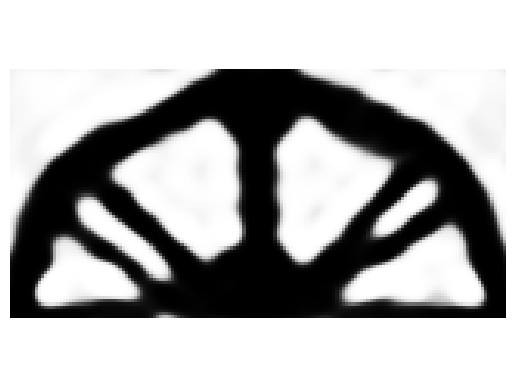

In [9]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.imshow(-tt, cmap='gray')
plt.axis('equal')
plt.axis('off')
plt.savefig("./mbb22.pdf",dpi=300)

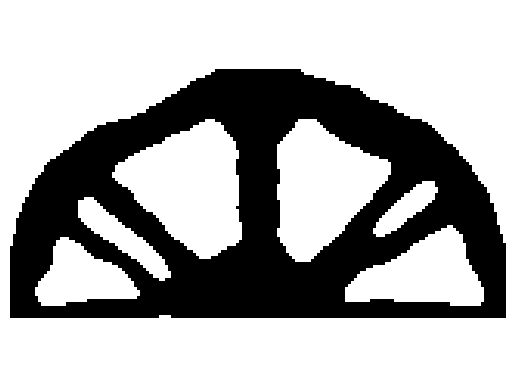

In [10]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.imshow(1-tt_clean, cmap='gray')
plt.axis('equal')
plt.axis('off')
plt.savefig("./mbb22_clean.pdf",dpi=300)